# 🕵️ Fake & AI-Generated Review Detector

**End-to-End ML Pipeline**

This notebook walks through:
1. Dataset loading & exploration
2. Special character & emoji feature analysis
3. Classical ML (TF-IDF + LR/SVM)
4. Ensemble methods (Random Forest, XGBoost)
5. Deep Learning (Bi-LSTM + BERT)
6. Model comparison & visualization
7. Single-review inference

> **Key insight:** AI-generated reviews tend to be clean and uniform—no emojis, no repeated `!!!`, no non-ASCII characters, and they love em-dashes `—` and ellipses `...`. We preserve these signals instead of stripping them.

## 0. Setup

In [5]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('✅ Setup complete')

✅ Setup complete


## 1. Load Dataset

In [6]:
from src.preprocessing import load_dataset

# Change csv_path to your actual CSV file if you have one:
# splits = load_dataset(csv_path='data/reviews.csv', text_col='text', label_col='label')

# Using synthetic dataset for demo:
splits = load_dataset()

train_df = splits['train_df']
val_df   = splits['val_df']
test_df  = splits['test_df']

print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
train_df[['text','label']].head(8)

[load_dataset] No CSV path provided — generating synthetic dataset.
[generate_sample_dataset] Created 1000 samples  (real=500, fake/AI=500)
[load_dataset] Label distribution: {1: 500, 0: 500}
[load_dataset] Split → train=700, val=100, test=200

Train: 700 | Val: 100 | Test: 200


,text,label
0,yoooo this actually works?? i'm shook fr fr 💀,0
1,"Overall, this is a well-crafted product that I...",1
2,My experience with this product has been unifo...,1
3,My experience with this product has been unifo...,1
4,"not gonna lie, i've had better... but for the ...",0
5,This is an excellent product that offers great...,1
6,yoooo this actually works?? i'm shook fr fr 💀,0
7,I am thoroughly impressed with this purchase. ...,1


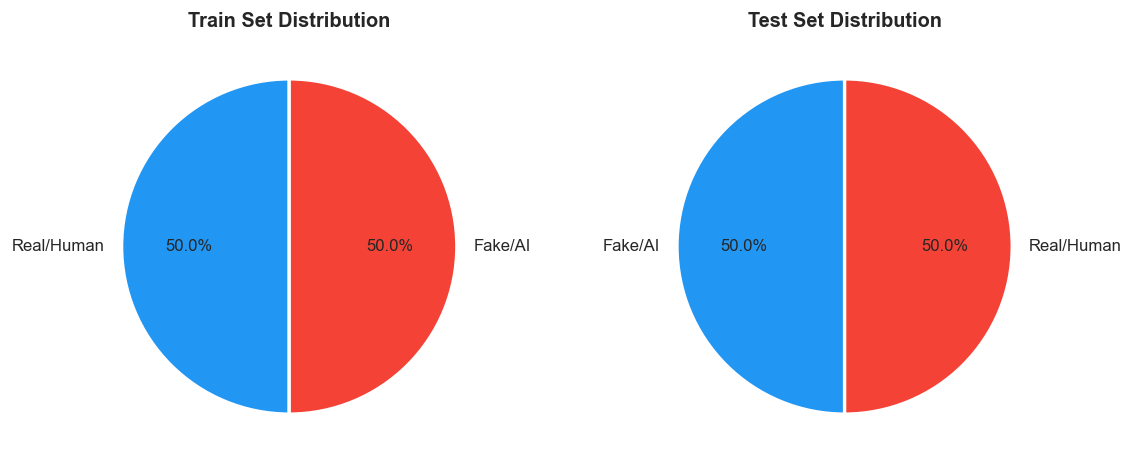

In [7]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = df['label'].map({0: 'Real/Human', 1: 'Fake/AI'}).value_counts()
    ax.pie(counts.values, labels=counts.index,
           autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
           startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'{name} Set Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Special Character & Emoji Feature Analysis

In [8]:
from src.feature_engineering import SpecialCharFeatureExtractor

extractor = SpecialCharFeatureExtractor()

# Extract features for full dataset
all_df   = splits['full_df'].copy()
feats_df = extractor.transform(all_df['text'].tolist())
feats_df['label'] = all_df['label'].values

print(f'Total features extracted: {len(extractor.feature_names)}')
print('\nFeature names:')
print(extractor.feature_names)

[WARNING] 'emoji' package not installed. Emoji features will be zeros.
Total features extracted: 44

Feature names:
['n_exclaim', 'exclaim_per_word', 'exclaim_per_sent', 'n_question', 'question_per_sent', 'n_ellipsis', 'ellipsis_per_sent', 'n_emdash', 'emdash_per_sent', 'n_comma', 'comma_per_sent', 'n_semicolon', 'n_colon', 'n_repeated_punct', 'n_quote', 'n_star', 'n_dollar', 'n_percent', 'punct_density', 'n_caps_words', 'caps_char_ratio', 'n_upper_chars', 'n_non_ascii', 'non_ascii_ratio', 'n_unicode_letter', 'n_modifier_chars', 'n_emojis', 'n_unique_emojis', 'emoji_diversity', 'emoji_word_ratio', 'n_face_emoji', 'n_symbol_emoji', 'n_hashtags', 'n_mentions', 'n_urls', 'has_url', 'char_entropy', 'punct_entropy', 'avg_word_len', 'avg_sent_len', 'n_words', 'n_sentences', 'n_chars', 'ai_signal_score']


In [9]:
# Compare means by class
comparison = feats_df.groupby('label').mean().T
comparison.columns = ['Real/Human', 'Fake/AI']
comparison['ratio_fake_to_real'] = (comparison['Fake/AI'] + 1e-6) / (comparison['Real/Human'] + 1e-6)
comparison = comparison.sort_values('ratio_fake_to_real', ascending=False)

print('\nTop features higher in Fake/AI reviews:')
print(comparison.head(10).round(4))
print('\nTop features higher in Real/Human reviews:')
print(comparison.tail(10).round(4))


Top features higher in Fake/AI reviews:
                 Real/Human   Fake/AI  ratio_fake_to_real
n_emdash             0.0000    0.1420         142001.0000
emdash_per_sent      0.0000    0.0710          71001.0000
comma_per_sent       0.0273    0.3650             13.3532
ai_signal_score      0.1269    0.8429              6.6422
n_comma              0.0820    0.5000              6.0975
avg_sent_len         5.0267   13.7663              2.7387
n_chars             64.3600  142.1760              2.2091
n_words             12.3500   22.7360              1.8410
avg_word_len         3.8289    5.2138              1.3617
char_entropy         4.1798    4.2340              1.0130

Top features higher in Real/Human reviews:
                  Real/Human  Fake/AI  ratio_fake_to_real
n_symbol_emoji        0.3720      0.0                 0.0
n_question            0.4380      0.0                 0.0
exclaim_per_sent      0.7445      0.0                 0.0
emoji_diversity       0.8240      0.0        

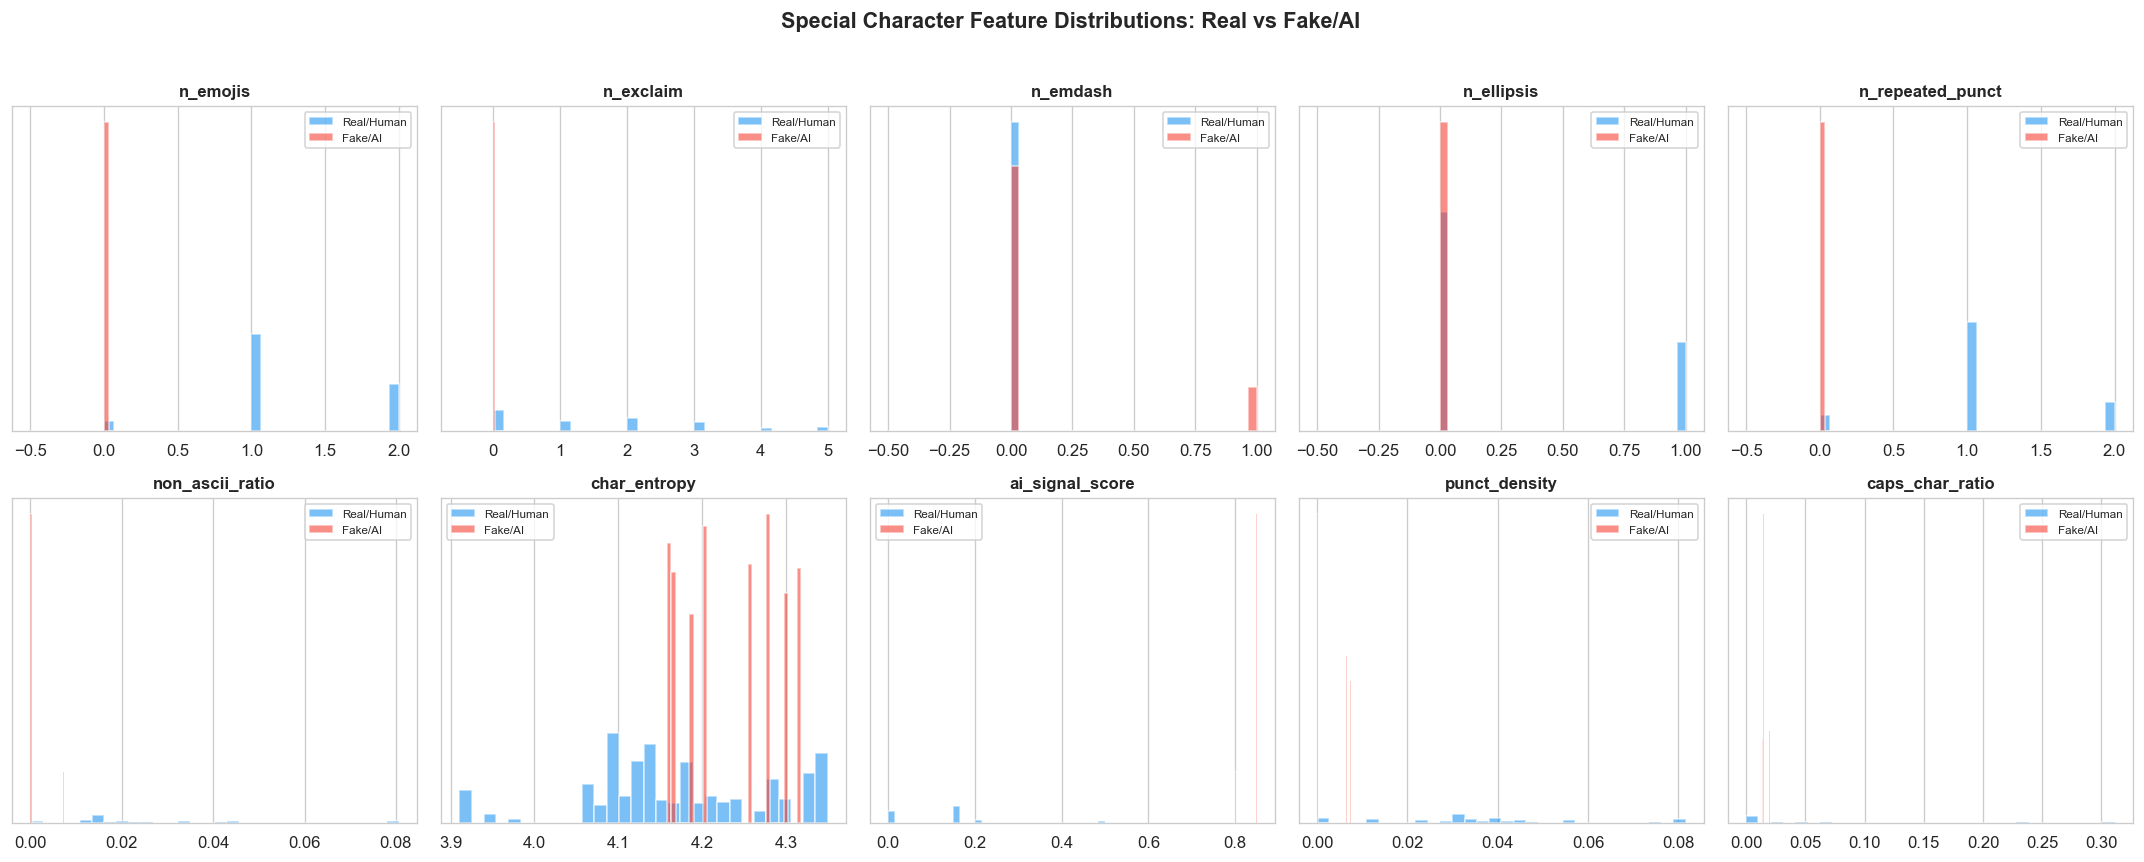

In [10]:
# Visual comparison — key special char features
key_features = [
    'n_emojis', 'n_exclaim', 'n_emdash', 'n_ellipsis',
    'n_repeated_punct', 'non_ascii_ratio', 'char_entropy',
    'ai_signal_score', 'punct_density', 'caps_char_ratio'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
palette = {0: '#2196F3', 1: '#F44336'}
label_names = {0: 'Real/Human', 1: 'Fake/AI'}

for i, feat in enumerate(key_features):
    for lbl, grp in feats_df.groupby('label'):
        data = grp[feat].clip(upper=grp[feat].quantile(0.95))
        axes[i].hist(data, bins=30, alpha=0.6, color=palette[lbl],
                     label=label_names[lbl], density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_yticks([])

fig.suptitle('Special Character Feature Distributions: Real vs Fake/AI',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Demo the extractor on specific examples
examples = [
    ('🤖 AI-style', 'This product exceeded all my expectations. The craftsmanship is '
     'truly exceptional—a testament to thoughtful engineering and design.'),
    ('👤 Human-style', 'omg i LOVE this!! 😍😍 best purchase ever tbh... '
     'kinda pricey but worth it 100%!! would def buy again 🛒✨'),
    ('💬 Spam', 'BEST PRODUCT EVER!!! BUY NOW!!! 5 STARS!!! AMAZING!!!'),
]

print(f'{"Type":<15} {"emojis":>7} {"exclaim":>8} {"emdash":>7} {"ellipsis":>9} '
      f'{"repeat_p":>9} {"non_ascii":>10} {"entropy":>9} {"AI_score":>9}')
print('-' * 90)
for label, text in examples:
    f = extractor.extract(text)
    print(f'{label:<15} {f["n_emojis"]:>7} {f["n_exclaim"]:>8} {f["n_emdash"]:>7} '
          f'{f["n_ellipsis"]:>9} {f["n_repeated_punct"]:>9} '
          f'{f["non_ascii_ratio"]:>10.3f} {f["char_entropy"]:>9.3f} '
          f'{f["ai_signal_score"]:>9.2f}')

Type             emojis  exclaim  emdash  ellipsis  repeat_p  non_ascii   entropy  AI_score
------------------------------------------------------------------------------------------
🤖 AI-style            0        0       1         0         0      0.008     4.214      0.80
👤 Human-style         3        4       0         1         3      0.039     4.611      0.00
💬 Spam                0       12       0         0         4      0.000     3.946      0.50


## 3. Classical ML — TF-IDF + Logistic Regression / SVM

In [12]:
from src.train_classical import train_classical_models

os.makedirs('models', exist_ok=True)
classical_results, bundle = train_classical_models(splits, save_dir='models')


BUILDING FEATURE MATRICES
  Training set:
  Feature matrix shape: (700, 2396)
  Validation set:
  Feature matrix shape: (100, 2396)
  Test set:
  Feature matrix shape: (200, 2396)

  ✅ Feature bundle saved to models/feature_bundle.pkl

TRAINING: Logistic Regression
  Val Accuracy : 1.0000
  Test Accuracy: 1.0000
  Test ROC-AUC : 1.0000

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       100
     Fake/AI       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

  💾 Saved → models\LogisticRegression.pkl

TRAINING: LinearSVC
  Val Accuracy : 1.0000
  Test Accuracy: 1.0000

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       100
     Fake/AI       1.00      1.00      1.00     

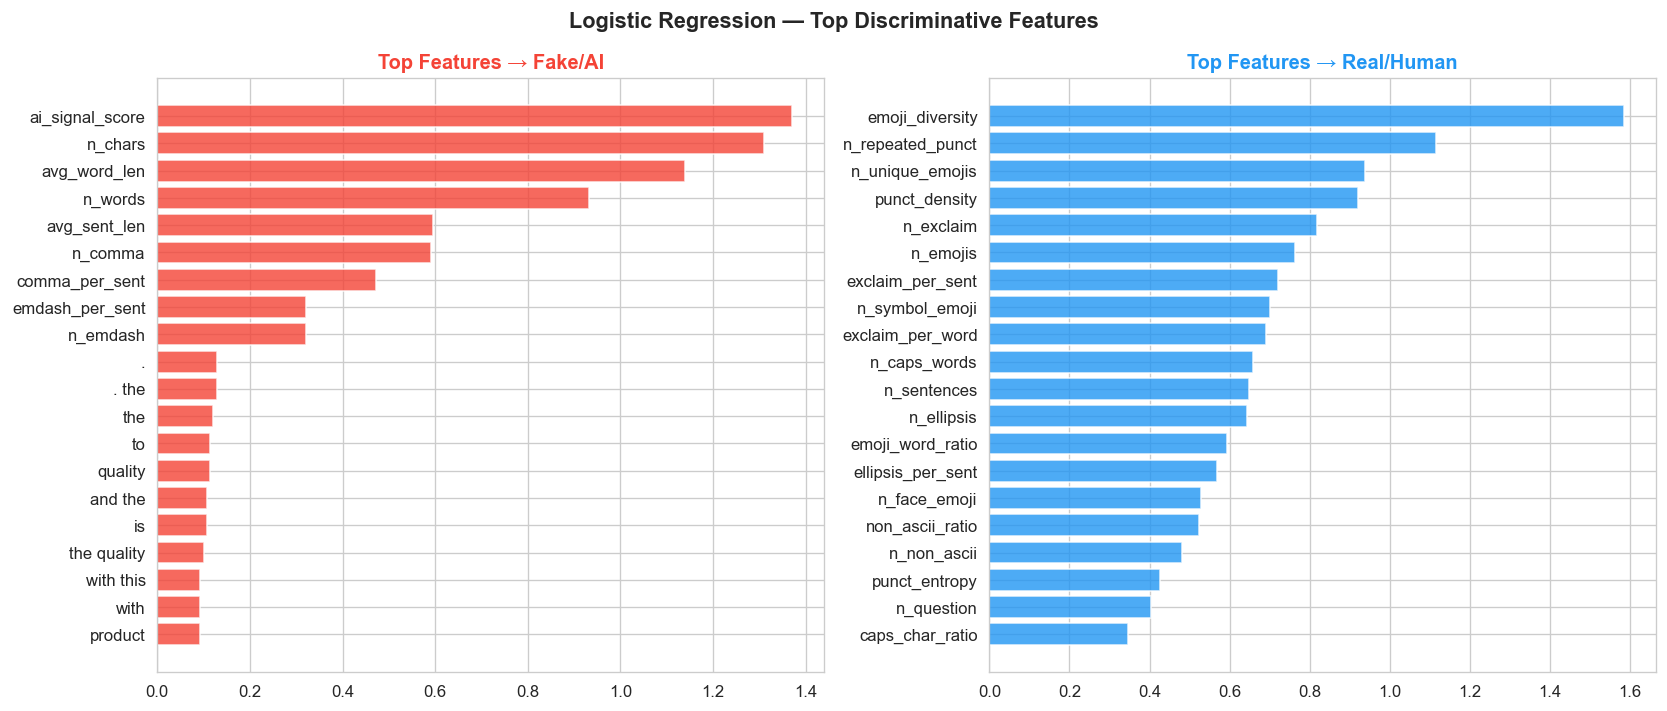

In [13]:
# Visualize TF-IDF top tokens (LogisticRegression)
import joblib
from src.train_classical import build_feature_matrix

lr_model  = joblib.load('models/LogisticRegression.pkl')
tfidf_w   = bundle['tfidf_word']
tfidf_c   = bundle['tfidf_char']
sp_trans  = bundle['special_transformer']

word_feats  = list(tfidf_w.get_feature_names_out())
char_feats  = [f'CHAR:{f}' for f in tfidf_c.get_feature_names_out()]
sp_feats    = sp_trans.get_feature_names_out()
all_feats   = word_feats + char_feats + list(sp_feats)

coef = lr_model.coef_[0]
top_fake = np.argsort(coef)[-20:][::-1]
top_real = np.argsort(coef)[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh([all_feats[i][:30] for i in top_fake], coef[top_fake], color='#F44336', alpha=0.8)
ax1.set_title('Top Features → Fake/AI', fontweight='bold', color='#F44336')
ax1.invert_yaxis()

ax2.barh([all_feats[i][:30] for i in top_real], np.abs(coef[top_real]), color='#2196F3', alpha=0.8)
ax2.set_title('Top Features → Real/Human', fontweight='bold', color='#2196F3')
ax2.invert_yaxis()

plt.suptitle('Logistic Regression — Top Discriminative Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Ensemble Models — Random Forest & XGBoost

In [14]:
from src.train_ensemble import train_ensemble_models

ensemble_results = train_ensemble_models(splits, bundle=bundle, save_dir='models')

[WARNING] xgboost not installed. Skipping XGBoost model.
  Feature matrix shape: (700, 2396)
  Feature matrix shape: (100, 2396)
  Feature matrix shape: (200, 2396)
  Feature matrix (train): (700, 2396)

TRAINING: Random Forest
  Val Accuracy : 1.0000
  Test Accuracy: 1.0000
  Test ROC-AUC : 1.0000

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       100
     Fake/AI       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

  💾 Saved → models\RandomForest.pkl

TRAINING: Gradient Boosting (sklearn) — using special char features only
  Val Accuracy : 1.0000
  Test Accuracy: 1.0000
  Test ROC-AUC : 1.0000

  Classification Report (Test):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       100
     Fake/AI    

## 5. Deep Learning — Bi-LSTM

In [17]:
from src.train_deep import train_bilstm

# Reduce epochs for quick demo; use epochs=15 for full training
bilstm_results = train_bilstm(splits, save_dir='models', epochs=5, batch_size=32)

ModuleNotFoundError: No module named 'torch'

## 5b. BERT Fine-tuning (optional — requires GPU for reasonable speed)

Uncomment and run the cell below if you want to fine-tune BERT.
Requires `transformers` installed and ideally a GPU.

In [ ]:
# from src.train_deep import train_bert
# bert_results = train_bert(splits, save_dir='models', epochs=3, batch_size=16)

## 6. Model Comparison & Evaluation Plots

In [ ]:
from src.evaluate import evaluate_all_models

os.makedirs('outputs', exist_ok=True)
results_df = evaluate_all_models(splits, models_dir='models', output_dir='outputs')

In [ ]:
# Display saved plots inline
from IPython.display import Image, display

for plot_file in ['model_accuracy.png', 'roc_curves.png',
                  'confusion_matrix.png', 'special_char_distributions.png']:
    path = f'outputs/{plot_file}'
    if os.path.exists(path):
        print(f'\n--- {plot_file} ---')
        display(Image(filename=path))

## 7. Single-Review Inference

In [ ]:
from src.evaluate import predict_single

test_reviews = [
    # Likely AI
    'This product exceeded all my expectations. The build quality is exceptional—'
    'truly a testament to modern craftsmanship and thoughtful design.',

    # Likely Human
    'omg i LOVE this!! 😍😍 best purchase ever tbh... kinda pricey but '
    'worth it 100%!! would def buy again 🛒✨',

    # Ambiguous — try your own!
    'Great product, works as expected. Delivery was fast. Would recommend to friends.',
    
    # Your custom review:
    'INSERT YOUR OWN REVIEW TEXT HERE',
]

for review in test_reviews:
    result = predict_single(
        review,
        model_path='models/LogisticRegression.pkl',
        bundle_path='models/feature_bundle.pkl'
    )
    emoji = '🤖' if result['prediction'] == 'Fake/AI' else '👤'
    print(f"\n{emoji} {result['prediction']}  (conf={result['confidence']}, "
          f"ai_score={result['ai_signal_score']})")
    print(f"   emojis={result['n_emojis']}, exclaim={result['n_exclaim']}, "
          f"emdash={result['n_emdash']}, repeated_punct={result['n_repeated_punct']}")
    print(f"   Text: {review[:80]}...")

## Summary

### Key Findings

| Signal | AI-Generated | Human-Written |
|---|---|---|
| Emojis | Rare / absent | Common, diverse |
| `!!!` repeated punct | Almost never | Very common |
| Em-dash `—` | Frequent | Rare |
| Non-ASCII chars | Near zero | Occasional (ñ, é, curly quotes) |
| ALL CAPS words | Almost never | Expressive use |
| Char entropy | Low (uniform) | Higher (noisy) |
| Sentence length | Long, uniform | Variable |

### Next Steps
- Collect or source a real-world labelled dataset (e.g., Amazon reviews + GPT-generated versions)
- Fine-tune BERT on your domain-specific data
- Add `perplexity` and `burstiness` features (GPTZero-style)
- Deploy as a FastAPI endpoint using `predict_single()`